In [1]:
import pandas as pd, numpy as np 
import matplotlib.pyplot as plt 

In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.svm import SVC 
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

In [5]:
# Load & Preprocess 
df=pd.read_csv("diabetes.csv")

In [6]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [7]:
zero_counts = (df == 0).sum()

In [8]:
zero_counts

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [9]:
# zero_cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] 
# df[zero_cols] = df[zero_cols].replace(0, np.nan) 

# df.fillna(df.median(), inplace=True)

In [10]:
print("shape is:",df.shape)

shape is: (768, 9)


In [11]:
print("First five Rows")
print(df.head())

First five Rows
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [12]:
X=df.drop('Outcome', axis=1)

In [13]:
y=df['Outcome'] 

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [15]:
scaler=StandardScaler() 


In [16]:
X_train=scaler.fit_transform(X_train) 

In [17]:
X_test=scaler.transform(X_test) 

In [18]:
# kNN 
k_values=[1, 3, 5, 7, 9, 33, 102, 300] 
results=[]

In [19]:
for k in k_values: 
    knn=KNeighborsClassifier(n_neighbors=k) 
    knn.fit(X_train, y_train) 
    y_pred=knn.predict(X_test) 
    results.append({
        'k': k,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

In [20]:
#Summary table
print("Summary Table\n")
results_df=pd.DataFrame(results)
print(results_df)

Summary Table

     k  Accuracy  Precision    Recall        F1
0    1  0.759740   0.660714  0.672727  0.666667
1    3  0.805195   0.698413  0.800000  0.745763
2    5  0.798701   0.693548  0.781818  0.735043
3    7  0.792208   0.701754  0.727273  0.714286
4    9  0.818182   0.728814  0.781818  0.754386
5   33  0.805195   0.755102  0.672727  0.711538
6  102  0.805195   0.765957  0.654545  0.705882
7  300  0.720779   0.833333  0.272727  0.410959


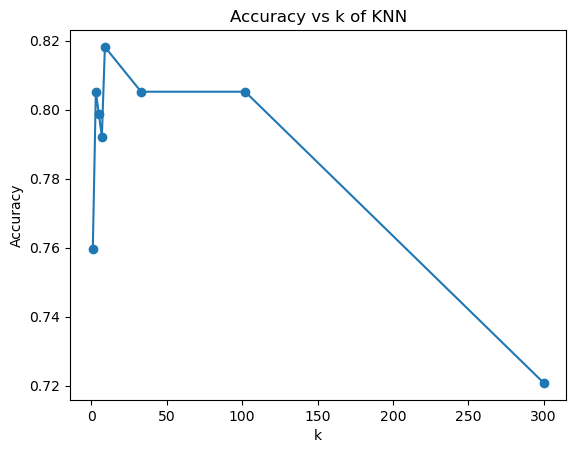

In [21]:
#Plot
plt.plot(results_df['k'], results_df['Accuracy'], marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k of KNN")
plt.show()

In [22]:
#SVM
svm=SVC(kernel='rbf')
svm.fit(X_train,y_train)
y_predicted_svm=svm.predict(X_test)

In [23]:
#Naive Bayes
nb=GaussianNB()
nb.fit(X_train, y_train)
y_predicted_nb=nb.predict(X_test)

In [24]:
# SVM Metrics
SVM_Accuracy=accuracy_score(y_test, y_predicted_svm)
SVM_Precision=precision_score(y_test, y_predicted_svm)
SVM_Recall=recall_score(y_test, y_predicted_svm)
SVM_F1=f1_score(y_test, y_predicted_svm)

In [25]:
svm_metrics={
    'Accuracy': SVM_Accuracy,
    'Precision': SVM_Precision,
    'Recall': SVM_Recall,
    'F1': SVM_F1
}


In [26]:
pd.DataFrame([svm_metrics])

,Accuracy,Precision,Recall,F1
0,0.824675,0.759259,0.745455,0.752294


In [27]:
# Naive Bayes
NB_Accuracy=accuracy_score(y_test, y_predicted_nb)
NB_Precision=precision_score(y_test, y_predicted_nb)
NB_Recall=recall_score(y_test, y_predicted_nb)
NB_F1=f1_score(y_test, y_predicted_nb)

In [28]:
nb_metrics={
    'Accuracy': NB_Accuracy,
    'Precision': NB_Precision,
    'Recall': NB_Recall,
    'F1': NB_F1
}

In [29]:
pd.DataFrame([nb_metrics])

,Accuracy,Precision,Recall,F1
0,0.766234,0.666667,0.690909,0.678571


In [30]:
print("SVM Confusion Matrix:\n",confusion_matrix(y_test,y_predicted_svm))
print("\n")
print("Naive Bayes Confusion Matrix:\n",confusion_matrix(y_test,y_predicted_nb))

SVM Confusion Matrix:
 [[86 13]
 [14 41]]


Naive Bayes Confusion Matrix:
 [[80 19]
 [17 38]]


In [31]:
#Best k
best_k_value=results_df.loc[results_df['Accuracy'].idxmax(),'k']
print("Best k is:",best_k_value)

Best k is: 9


In [32]:
#Comparison table
best_knn_metrics=results_df[results_df['k']==best_k_value].iloc[0]

In [33]:
best_knn_metrics

k            9.000000
Accuracy     0.818182
Precision    0.728814
Recall       0.781818
F1           0.754386
Name: 4, dtype: float64

In [34]:
comparison=pd.DataFrame([
    ['kNN (k='+str(best_k_value)+')',best_knn_metrics['Accuracy'],best_knn_metrics['Precision'],best_knn_metrics['Recall'],best_knn_metrics['F1']],
    ['SVM',svm_metrics['Accuracy'],svm_metrics['Precision'],svm_metrics['Recall'],svm_metrics['F1']],
    ['Naive Bayes',nb_metrics['Accuracy'],nb_metrics['Precision'],nb_metrics['Recall'],nb_metrics['F1']]],
    columns=['Model','Accuracy','Precision','Recall','F1-score'])

In [35]:
print("Comparison Table\n \n",comparison)

Comparison Table
 
          Model  Accuracy  Precision    Recall  F1-score
0    kNN (k=9)  0.818182   0.728814  0.781818  0.754386
1          SVM  0.824675   0.759259  0.745455  0.752294
2  Naive Bayes  0.766234   0.666667  0.690909  0.678571


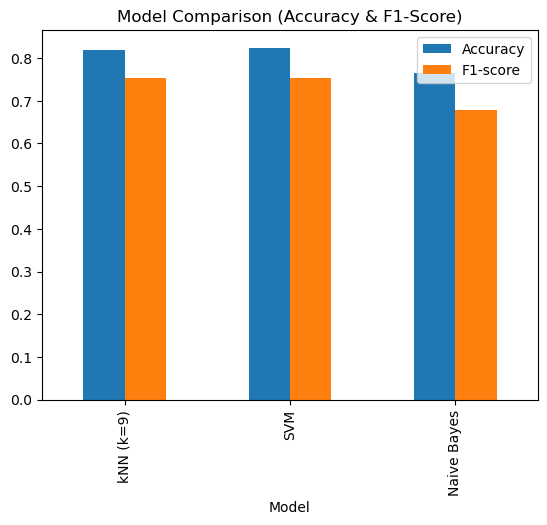

In [36]:
#Bar chart
comparison.set_index('Model')[['Accuracy','F1-score']].plot(kind='bar')
plt.title("Model Comparison (Accuracy & F1-Score)") 
plt.show()